# Firefly Algorithm (FA) — Assignment วิชา Optimization

อัลกอริทึมเขียนตามสไลด์เท่านั้น — ใช้เฉพาะ `numpy`, `matplotlib`, `time` และไม่ใช้ Optimization Library ใดๆ

**กฎพื้นฐาน 3 ข้อ**
1. หิ่งห้อยทุกตัวดึงดูดกันได้ทั้งหมดโดยไม่แบ่งแยก
2. หิ่งห้อยที่สว่างน้อยกว่าเคลื่อนที่เข้าหาตัวที่สว่างกว่า แรงดึงดูดลดลงตามระยะทาง — ถ้าไม่มีตัวใดสว่างกว่า จะเดินแบบสุ่ม
3. ความสว่างถูกกำหนดจากฟังก์ชันเป้าหมาย — งานนี้หาค่าต่ำสุด จึงใช้ $I = -f(\mathbf{x})$

**สมการ**

| ชื่อ | สมการ |
|---|---|
| ความน่าดึงดูดใจ | $\beta(r) = \beta_0 \, e^{-\gamma r^m}$, $\;m = 2$ |
| ระยะทาง | $r_{ij} = \sqrt{\sum_k (x_{i,k} - x_{j,k})^2}$ |
| การเคลื่อนที่ | $\mathbf{x}_i^{t+1} = \mathbf{x}_i^t + \beta_0 e^{-\gamma r_{ij}^2} (\mathbf{x}_j^t - \mathbf{x}_i^t) + \alpha(\text{rand} - 0.5)$ |
| เดินสุ่ม (ไม่มีตัวใดสว่างกว่า) | $\mathbf{x}_i^{t+1} = \mathbf{x}_i^t + \alpha(\text{rand} - 0.5)$ |

rand สุ่มจาก $U(0,1)$ แยกกันทุกมิติ และ $\alpha$ คงที่ตลอดการทำงาน

**ลำดับการทำงาน (flowchart)**
1. กำหนดพารามิเตอร์ และสร้างประชากรหิ่งห้อยเริ่มต้นแบบสุ่มในขอบเขต
2. ประเมิน fitness ของหิ่งห้อยทุกตัวด้วย objective function
3. อัปเดตความสว่าง (light intensity)
4. จัดอันดับหิ่งห้อยและหาตัวที่ดีที่สุด
5. เคลื่อนที่หิ่งห้อยทุกตัวไปหาคำตอบที่ดีกว่า
6. ถ้ายังไม่ถึงจำนวนรอบสูงสุด กลับไปข้อ 2 — ถ้าครบแล้ว ให้ผลลัพธ์ที่ดีที่สุด

## พารามิเตอร์

In [35]:
import time

import numpy as np
import matplotlib.pyplot as plt

# ===== flowchart ขั้นที่ 1: กำหนดพารามิเตอร์ (ปรับได้ที่นี่ที่เดียว) =====
n_fireflies = 25    # จำนวนหิ่งห้อย
max_iter = 100      # จำนวนรอบสูงสุด (ต้องไม่น้อยกว่า 20)
beta0 = 1.0         # β0 : ความน่าดึงดูดใจเมื่อ r = 0 (สมการความน่าดึงดูดใจ)
gamma = 1.0         # γ  : สัมประสิทธิ์การดูดกลืนแสง (สมการความน่าดึงดูดใจ)
m = 2               # m  : เลขชี้กำลังของ r ในสมการความน่าดึงดูดใจ β(r) = β0·exp(-γ·r^m)
alpha = 0.2         # α  : ค่าคงที่ของพจน์สุ่ม (คงที่ตลอดการทำงาน) (สมการการเคลื่อนที่)
n_runs = 30         # จำนวนการรันอิสระต่อฟังก์ชัน
seed = 42           # seed หลัก — run ที่ k ใช้ seed + k

snapshot_iters = [0, 5, 20, max_iter]   # รอบที่วาดตำแหน่งหิ่งห้อยบน contour

assert max_iter >= 20, "max_iter ต้องไม่น้อยกว่า 20"

## ฟังก์ชันทดสอบ (2 มิติ, หาค่าต่ำสุด)

| ฟังก์ชัน | สูตร | ขอบเขต | ค่าต่ำสุด |
|---|---|---|---|
| Rosenbrock | $f(x, y) = (1 - x)^2 + 100(y - x^2)^2$ | $[-5, 5]$ | $0$ ที่ $(1, 1)$ |
| Rastrigin | $f(x, y) = 20 + x^2 + y^2 - 10[\cos 2\pi x + \cos 2\pi y]$ | $[-5.12, 5.12]$ | $0$ ที่ $(0, 0)$ |

In [36]:
def rosenbrock(p):
    # f(x, y) = (1 - x)^2 + 100(y - x^2)^2
    x, y = p
    return (1 - x) ** 2 + 100 * (y - x ** 2) ** 2


def rastrigin(p):
    # f(x, y) = 20 + x^2 + y^2 - 10[cos(2πx) + cos(2πy)]
    x, y = p
    return 20 + x ** 2 + y ** 2 - 10 * (np.cos(2 * np.pi * x) + np.cos(2 * np.pi * y))


TEST_FUNCTIONS = {
    "Rosenbrock": {"objective": rosenbrock, "lb": [-5.0, -5.0], "ub": [5.0, 5.0], "x_star": [1.0, 1.0]},
    "Rastrigin": {"objective": rastrigin, "lb": [-5.12, -5.12], "ub": [5.12, 5.12], "x_star": [0.0, 0.0]},
}

## ตัวอัลกอริทึม Firefly

`firefly_algorithm()` ทำงานตาม flowchart ขั้นที่ 1–6 ทีละขั้น

- ความสว่าง $I$ คำนวณครั้งเดียวในขั้นที่ 2–3 ของแต่ละรอบ แล้วใช้ตัดสินว่าใครสว่างกว่าใครตลอดขั้นที่ 5
- ในขั้นที่ 5 หิ่งห้อย $i$ บินเข้าหา $j$ **ทุกตัว** ที่สว่างกว่า โดย $\mathbf{x}_j^t$ คือตำแหน่งของ $j$ ณ ต้นรอบ
- ผลลัพธ์ที่ดีที่สุด (ขั้นที่ 6) คือหิ่งห้อยอันดับ 1 ที่ดีที่สุดจากการจัดอันดับในขั้นที่ 4 ของทุกรอบ

พารามิเตอร์ `verbose` และ `decimals` ใช้สำหรับโหมดคำนวณด้วยมือเท่านั้น (พิมพ์ทุกขั้น และปัดทศนิยมทุกค่าก่อนใช้ต่อ)

In [37]:
def _v(a):
    # แสดงตัวเลข/เวกเตอร์ทศนิยม 4 ตำแหน่ง (ใช้ตอนพิมพ์โหมดคำนวณด้วยมือ)
    if np.ndim(a) == 0:
        return f"{float(a):.4f}"
    return "(" + ", ".join(f"{float(v):.4f}" for v in a) + ")"


def firefly_algorithm(objective, lb, ub, n_fireflies=n_fireflies, max_iter=max_iter, beta0=beta0,
                      gamma=gamma, m=m, alpha=alpha, seed=seed, init_positions=None,
                      verbose=False, decimals=None):
    # decimals: ปัดทุกค่ากลางทางก่อนใช้ต่อ (โหมดคำนวณด้วยมือ) เพื่อให้คำนวณตามบนสไลด์ได้ตรงทุกหลัก
    # บวก 1e-9 ตามเครื่องหมายก่อนปัด เพื่อให้ปัด .5 ขึ้นแบบที่คำนวณด้วยมือ (np.round ปัด .5 ไปหาเลขคู่)
    if decimals is not None:
        rnd = lambda a: np.round(np.asarray(a) + np.sign(a) * 1e-9, decimals)
    else:
        rnd = lambda a: a
    rng = np.random.default_rng(seed)
    lb = np.asarray(lb, dtype=float)
    ub = np.asarray(ub, dtype=float)
    dim = lb.size
    start = time.perf_counter()

    # ===== flowchart ขั้นที่ 1: สร้างประชากรหิ่งห้อยเริ่มต้นแบบสุ่มในขอบเขต =====
    if init_positions is None:
        x = rng.uniform(lb, ub, size=(n_fireflies, dim))
    else:
        x = np.array(init_positions, dtype=float)
        n_fireflies = len(x)
    x = rnd(x)

    history = [x.copy()]          # ตำแหน่งหิ่งห้อยทุกรอบ (index 0 = ประชากรเริ่มต้น) ใช้วาด contour
    best_per_iter = []            # best fitness ของแต่ละ iteration ใช้วาด convergence curve
    best_x, best_f = None, np.inf

    for t in range(1, max_iter + 1):
        if verbose:
            print("=" * 80)
            print(f"ITERATION {t}")
            print("=" * 80)

        # ===== flowchart ขั้นที่ 2: ประเมิน fitness ของหิ่งห้อยทุกตัวด้วย objective function =====
        f = np.array([rnd(objective(xi)) for xi in x])

        # ===== flowchart ขั้นที่ 3: อัปเดตความสว่าง — กฎข้อ 3: I = -f(x) =====
        I = -f

        # ===== flowchart ขั้นที่ 4: จัดอันดับหิ่งห้อย (สว่างมาก -> น้อย) และหาตัวที่ดีที่สุด =====
        order = np.argsort(-I, kind="stable")
        b = order[0]
        best_per_iter.append(f[b])
        if f[b] < best_f:
            best_x, best_f = x[b].copy(), f[b]

        if verbose:
            print("ขั้นที่ 2-3: ประเมิน fitness และความสว่าง I = -f")
            for i in range(n_fireflies):
                print(f"   หิ่งห้อย {i + 1}: x = {_v(x[i])}   f = {_v(f[i])}   I = {_v(I[i])}")
            print("ขั้นที่ 4: จัดอันดับ (สว่างมากที่สุดก่อน)")
            for rank, i in enumerate(order, start=1):
                print(f"   อันดับ {rank}: หิ่งห้อย {i + 1}  (I = {_v(I[i])})")
            print(f"   -> ตัวที่ดีที่สุดในรอบนี้: หิ่งห้อย {b + 1}  f = {_v(f[b])}")
            print("ขั้นที่ 5: เคลื่อนที่")

        # ===== flowchart ขั้นที่ 5: เคลื่อนที่หิ่งห้อยทุกตัวไปหาคำตอบที่ดีกว่า =====
        x_t = x.copy()                # x(t): ตำแหน่ง ณ ต้นรอบ ใช้เป็น x_j ในสมการการเคลื่อนที่
        x_new = x.copy()              # x(t+1): ตำแหน่งที่กำลังอัปเดต
        for i in range(n_fireflies):
            moved = False
            for j in range(n_fireflies):          # กฎข้อ 1: ทุกตัวดึงดูดกันได้ทั้งหมด -> เทียบทุกคู่
                if I[j] > I[i]:                   # กฎข้อ 2: ตัวที่สว่างน้อยกว่าเคลื่อนเข้าหาตัวที่สว่างกว่า
                    x_i = x_new[i].copy()     # ตำแหน่งปัจจุบันของ i (copy เพื่อไม่ให้ค่าเปลี่ยนตามเมื่ออัปเดต)
                    x_j = x_t[j]
                    diff = rnd(x_j - x_i)                              # (x_j - x_i)
                    r_ij = rnd(np.sqrt(np.sum((x_i - x_j) ** 2)))      # สมการระยะทาง r_ij = sqrt(Σ(x_i,k - x_j,k)²)
                    r_m = rnd(r_ij ** m)                               # r_ij^m  (m = 2)
                    beta = rnd(beta0 * np.exp(-gamma * r_m))           # สมการความน่าดึงดูดใจ β = β0·exp(-γ·r^m)
                    rand = rnd(rng.random(dim))                        # rand ~ U(0,1) แยกกันทุกมิติ
                    random_term = rnd(alpha * (rand - 0.5))            # α·(rand - 0.5)
                    attraction = rnd(beta * diff)                      # β0·exp(-γ·r_ij²)·(x_j - x_i)
                    x_new[i] = rnd(x_i + attraction + random_term)     # สมการการเคลื่อนที่
                    moved = True
                    if verbose:
                        print(f"   [i={i + 1} -> j={j + 1}]  I_{j + 1} = {_v(I[j])} > I_{i + 1} = {_v(I[i])}  -> เคลื่อนที่เข้าหา")
                        print(f"      x_i = {_v(x_i)}   x_j = {_v(x_j)}")
                        print(f"      x_j - x_i = {_v(diff)}")
                        print(f"      r_ij   = sqrt({' + '.join(f'({d:.4f})^2' for d in -diff)}) = {_v(r_ij)}")
                        print(f"      r_ij^2 = {_v(r_ij)}^2 = {_v(r_m)}")
                        print(f"      beta   = {beta0} * exp(-{gamma} * {_v(r_m)}) = {_v(beta)}")
                        print(f"      beta * (x_j - x_i) = {_v(attraction)}")
                        print(f"      rand = {_v(rand)}   ->   alpha*(rand - 0.5) = {alpha} * {_v(rand - 0.5)} = {_v(random_term)}")
                        print(f"      x_i(t+1) = {_v(x_i)} + {_v(attraction)} + {_v(random_term)} = {_v(x_new[i])}")
                elif verbose and i != j:
                    print(f"   [i={i + 1} -> j={j + 1}]  I_{j + 1} = {_v(I[j])} > I_{i + 1} = {_v(I[i])} ?  ไม่ -> ไม่เคลื่อนเข้าหา")

            if not moved:
                # กฎข้อ 2: ไม่มีตัวใดสว่างกว่า -> เดินแบบสุ่ม  x_i(t+1) = x_i(t) + α·(rand - 0.5)
                rand = rnd(rng.random(dim))
                random_term = rnd(alpha * (rand - 0.5))
                x_i = x_new[i].copy()
                x_new[i] = rnd(x_i + random_term)
                if verbose:
                    print(f"   หิ่งห้อย {i + 1}: ไม่มีตัวใดสว่างกว่า -> เดินแบบสุ่ม")
                    print(f"      rand = {_v(rand)}   ->   alpha*(rand - 0.5) = {alpha} * {_v(rand - 0.5)} = {_v(random_term)}")
                    print(f"      x_i(t+1) = {_v(x_i)} + {_v(random_term)} = {_v(x_new[i])}")

        x = x_new
        history.append(x.copy())

        # ===== flowchart ขั้นที่ 6: ครบจำนวนรอบสูงสุดหรือยัง =====
        if verbose:
            if t < max_iter:
                print(f"ขั้นที่ 6: t = {t} < max_iter = {max_iter} -> กลับไปขั้นที่ 2\n")
            else:
                print(f"ขั้นที่ 6: t = {t} = max_iter -> หยุด และให้ผลลัพธ์ที่ดีที่สุด\n")

    return {
        "best_x": best_x,                         # ผลลัพธ์ที่ดีที่สุด (flowchart ขั้นที่ 6)
        "best_f": best_f,
        "best_per_iter": np.array(best_per_iter),
        "history": history,
        "runtime": time.perf_counter() - start,
    }

## โหมดคำนวณด้วยมือ

หิ่งห้อย 3 ตัว (ตำแหน่งเริ่มต้นกำหนดเอง), seed คงที่, 2 iterations บน Rosenbrock
ทุกค่าปัดเป็นทศนิยม 4 ตำแหน่ง **ก่อน** นำไปใช้ขั้นถัดไป → คำนวณตามบนสไลด์ได้ตรงทุกหลัก

ตำแหน่งเริ่มต้น: $(0, 0)$ มี $f = 1$ · $(0.5, 0.5)$ มี $f = 0.25 + 100(0.25)^2 = 6.5$ · $(-0.5, 1)$ มี $f = 2.25 + 100(0.75)^2 = 58.5$

In [38]:
def hand_calculation_demo(init_positions=((0.0, 0.0), (0.5, 0.5), (-0.5, 1.0)), demo_seed=7, n_iter=2):
    info = TEST_FUNCTIONS["Rosenbrock"]
    print("โหมดคำนวณด้วยมือ — Firefly Algorithm บน Rosenbrock")
    print(f"พารามิเตอร์: beta0 = {beta0}, gamma = {gamma}, m = {m}, alpha = {alpha}, seed = {demo_seed}")
    print("x_i(t+1) = x_i(t) + beta0*exp(-gamma*r_ij^2)*(x_j - x_i) + alpha*(rand - 0.5)\n")
    print("ขั้นที่ 1: ประชากรเริ่มต้น")
    for k, p in enumerate(init_positions, start=1):
        print(f"   หิ่งห้อย {k}: x = {_v(p)}")
    print()
    result = firefly_algorithm(info["objective"], info["lb"], info["ub"], max_iter=n_iter, seed=demo_seed,
                               init_positions=init_positions, verbose=True, decimals=4)
    print(f"ตำแหน่งหลังรอบที่ {n_iter}:")
    for k, p in enumerate(result["history"][-1], start=1):
        print(f"   หิ่งห้อย {k}: x = {_v(p)}")
    print(f"\nผลลัพธ์ที่ดีที่สุด: x = {_v(result['best_x'])}   f = {_v(result['best_f'])}")
    return result


hand_result = hand_calculation_demo()

โหมดคำนวณด้วยมือ — Firefly Algorithm บน Rosenbrock
พารามิเตอร์: beta0 = 1.0, gamma = 1.0, m = 2, alpha = 0.2, seed = 7
x_i(t+1) = x_i(t) + beta0*exp(-gamma*r_ij^2)*(x_j - x_i) + alpha*(rand - 0.5)

ขั้นที่ 1: ประชากรเริ่มต้น
   หิ่งห้อย 1: x = (0.0000, 0.0000)
   หิ่งห้อย 2: x = (0.5000, 0.5000)
   หิ่งห้อย 3: x = (-0.5000, 1.0000)

ITERATION 1
ขั้นที่ 2-3: ประเมิน fitness และความสว่าง I = -f
   หิ่งห้อย 1: x = (0.0000, 0.0000)   f = 1.0000   I = -1.0000
   หิ่งห้อย 2: x = (0.5000, 0.5000)   f = 6.5000   I = -6.5000
   หิ่งห้อย 3: x = (-0.5000, 1.0000)   f = 58.5000   I = -58.5000
ขั้นที่ 4: จัดอันดับ (สว่างมากที่สุดก่อน)
   อันดับ 1: หิ่งห้อย 1  (I = -1.0000)
   อันดับ 2: หิ่งห้อย 2  (I = -6.5000)
   อันดับ 3: หิ่งห้อย 3  (I = -58.5000)
   -> ตัวที่ดีที่สุดในรอบนี้: หิ่งห้อย 1  f = 1.0000
ขั้นที่ 5: เคลื่อนที่
   [i=1 -> j=2]  I_2 = -6.5000 > I_1 = -1.0000 ?  ไม่ -> ไม่เคลื่อนเข้าหา
   [i=1 -> j=3]  I_3 = -58.5000 > I_1 = -1.0000 ?  ไม่ -> ไม่เคลื่อนเข้าหา
   หิ่งห้อย 1: ไม่มีตัวใดสว่

## ผลการทดลอง

รันอิสระ `n_runs` ครั้งต่อฟังก์ชัน (run ที่ $k$ ใช้ seed = `seed + k`)

In [39]:
def run_experiments(name):
    info = TEST_FUNCTIONS[name]
    runs = [firefly_algorithm(info["objective"], info["lb"], info["ub"], seed=seed + k) for k in range(n_runs)]
    return {
        "name": name,
        "runs": runs,
        "best_f": np.array([r["best_f"] for r in runs]),
        "runtime": np.array([r["runtime"] for r in runs]),
        "best_per_iter": np.stack([r["best_per_iter"] for r in runs]),
    }


results = {name: run_experiments(name) for name in TEST_FUNCTIONS}

print(f"{'Function':<12}{'Best':>14}{'Mean':>14}{'Worst':>14}{'Average Runtime (s)':>22}")
print("-" * 76)
for name, R in results.items():
    print(f"{name:<12}{R['best_f'].min():>14.6e}{R['best_f'].mean():>14.6e}{R['best_f'].max():>14.6e}"
          f"{R['runtime'].mean():>22.4f}")
print(f"\n(n_runs = {n_runs}, n_fireflies = {n_fireflies}, max_iter = {max_iter})")

Function              Best          Mean         Worst   Average Runtime (s)
----------------------------------------------------------------------------
Rosenbrock    2.845586e-05  7.324868e-03  4.300487e-02                0.1828
Rastrigin     3.945853e-03  2.496728e+00  6.831308e+00                0.1786

(n_runs = 30, n_fireflies = 25, max_iter = 100)


### Convergence Curve
ค่าเฉลี่ยของ best fitness ในแต่ละ iteration จากทุก run (แกน y แบบ log)

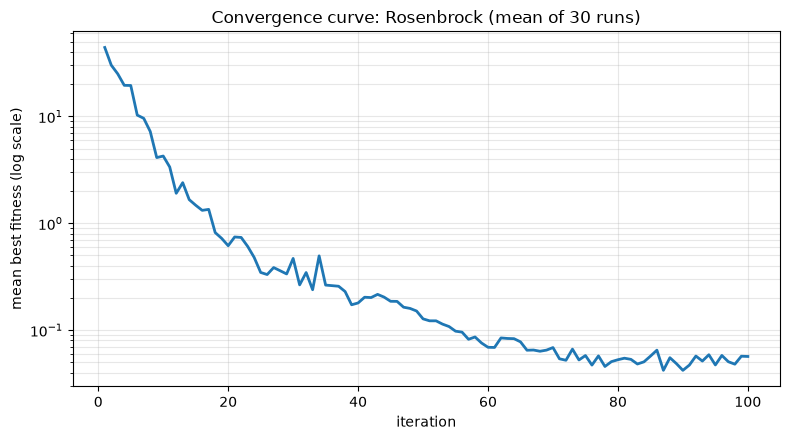

saved: fa_convergence_rosenbrock.png


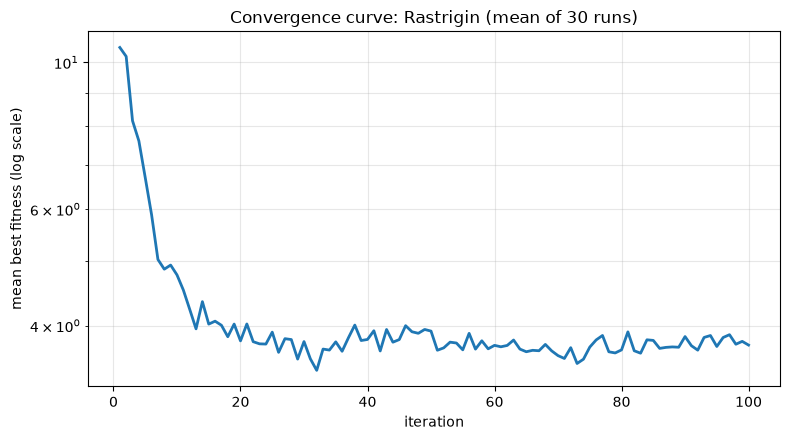

saved: fa_convergence_rastrigin.png


In [40]:
def plot_convergence(R):
    mean_curve = R["best_per_iter"].mean(axis=0)
    iters = np.arange(1, len(mean_curve) + 1)
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(iters, mean_curve, lw=2)
    ax.set_yscale("log")
    ax.set(xlabel="iteration", ylabel="mean best fitness (log scale)",
           title=f"Convergence curve: {R['name']} (mean of {n_runs} runs)")
    ax.grid(alpha=0.3, which="both")
    fig.tight_layout()
    filename = f"fa_convergence_{R['name'].lower()}.png"
    fig.savefig(filename, dpi=150)
    plt.show()
    print("saved:", filename)


for R in results.values():
    plot_convergence(R)

### ตำแหน่งหิ่งห้อยบน contour ที่ iteration 0, 5, 20 และรอบสุดท้าย (run แรก)

iteration 0 = ประชากรเริ่มต้น, iteration $t$ = ตำแหน่งหลังเคลื่อนที่รอบที่ $t$ · ⭐ = ค่าต่ำสุดจริง

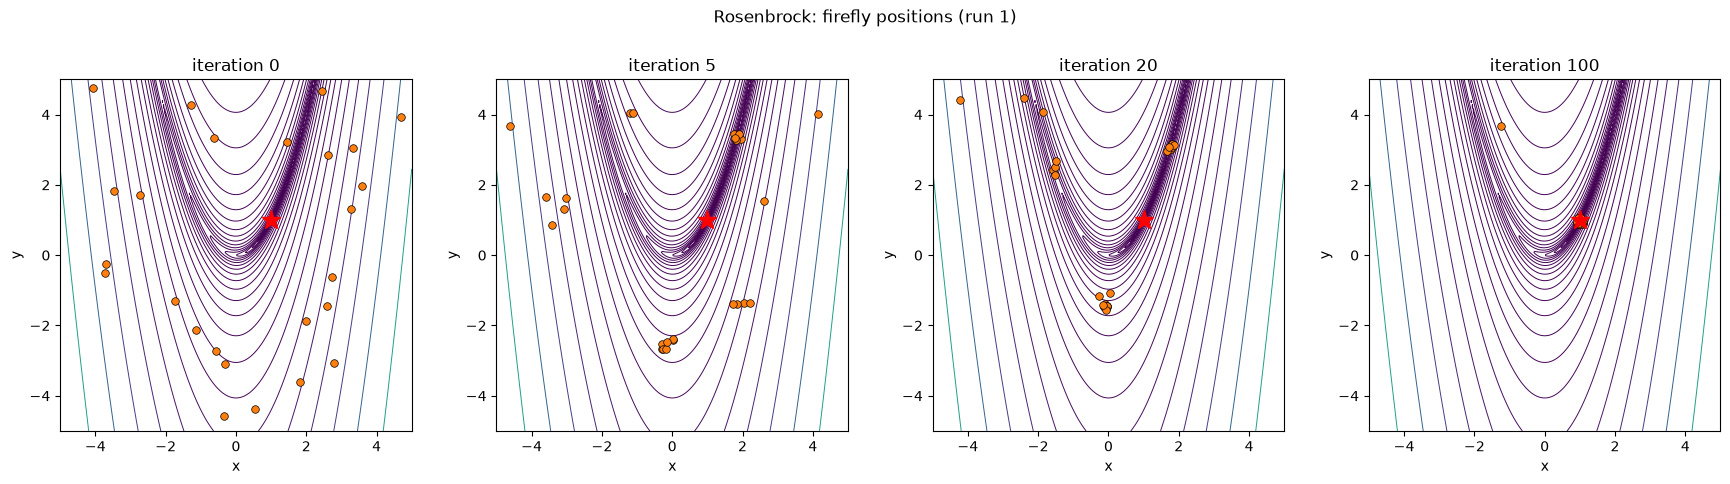

saved: fa_contour_rosenbrock.png


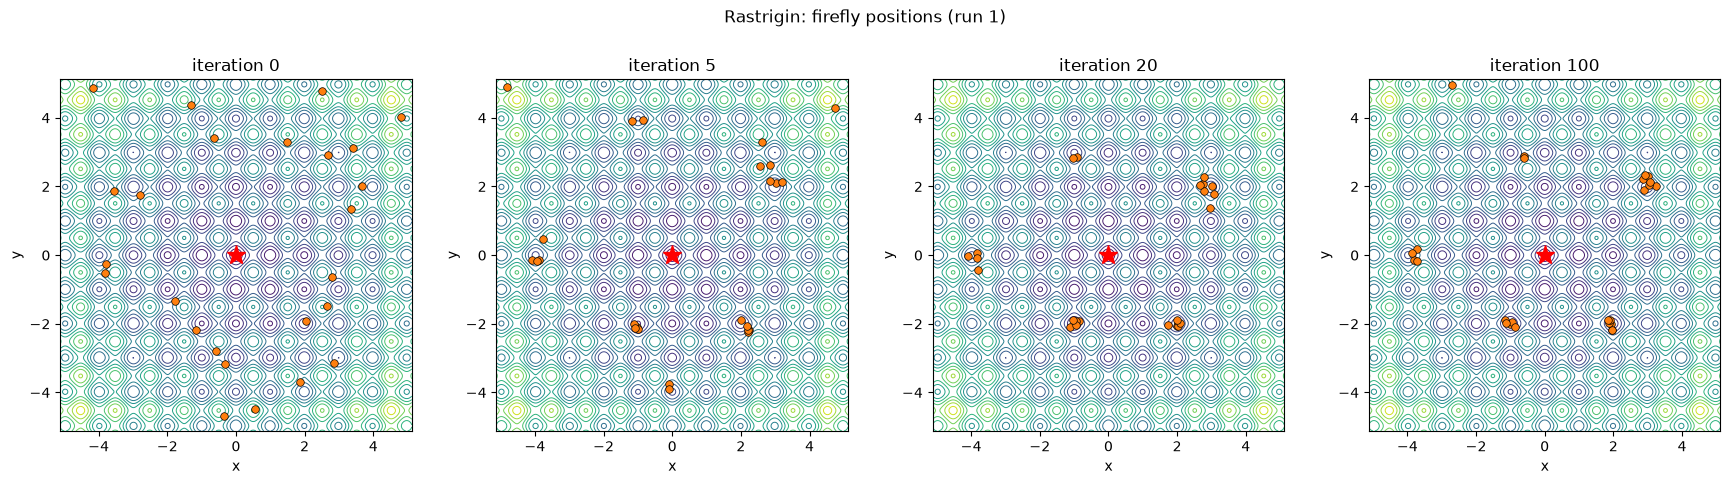

saved: fa_contour_rastrigin.png


In [41]:
def plot_contour_snapshots(R):
    info = TEST_FUNCTIONS[R["name"]]
    history = R["runs"][0]["history"]
    lb, ub = info["lb"], info["ub"]
    gx = np.linspace(lb[0], ub[0], 300)
    gy = np.linspace(lb[1], ub[1], 300)
    GX, GY = np.meshgrid(gx, gy)
    GZ = info["objective"]((GX, GY))
    levels = np.logspace(-1, np.log10(GZ.max()), 25) if R["name"] == "Rosenbrock" else 15

    fig, axes = plt.subplots(1, len(snapshot_iters), figsize=(4.4 * len(snapshot_iters), 4.6))
    for ax, t in zip(axes, snapshot_iters):
        P = history[t]
        ax.contour(GX, GY, GZ, levels=levels, cmap="viridis", linewidths=0.7)
        ax.scatter(P[:, 0], P[:, 1], s=30, c="tab:orange", edgecolors="k", linewidths=0.5, zorder=3)
        ax.plot(*info["x_star"], "r*", ms=14, zorder=4)
        ax.set(xlim=(lb[0], ub[0]), ylim=(lb[1], ub[1]), xlabel="x", ylabel="y", title=f"iteration {t}")
        ax.set_aspect("equal")
    fig.suptitle(f"{R['name']}: firefly positions (run 1)")
    fig.tight_layout(rect=(0, 0, 1, 0.93))
    filename = f"fa_contour_{R['name'].lower()}.png"
    fig.savefig(filename, dpi=150)
    plt.show()
    print("saved:", filename)


for R in results.values():
    plot_contour_snapshots(R)

## ตารางเทียบโค้ดกับสไลด์

| ส่วนของโค้ด | กฎ / สมการ / ขั้นตอน | หัวข้อในสไลด์ |
|---|---|---|
| ตัวแปร `n_fireflies`, `max_iter`, `beta0`, `gamma`, `m`, `alpha` | flowchart ขั้นที่ 1: กำหนดพารามิเตอร์ | Flowchart |
| `x = rng.uniform(lb, ub, size=(n_fireflies, dim))` | flowchart ขั้นที่ 1: สร้างประชากรเริ่มต้นแบบสุ่มในขอบเขต | Flowchart |
| `f = np.array([objective(xi) for xi in x])` | flowchart ขั้นที่ 2: ประเมิน fitness | Flowchart |
| `I = -f` | flowchart ขั้นที่ 3 + **กฎข้อ 3**: ความสว่างจากฟังก์ชันเป้าหมาย ($I = -f$) | กฎพื้นฐาน 3 ข้อ |
| `order = np.argsort(-I)` และ `b = order[0]` | flowchart ขั้นที่ 4: จัดอันดับและหาตัวที่ดีที่สุด | Flowchart |
| `for j in range(n_fireflies)` | **กฎข้อ 1**: ทุกตัวดึงดูดกันได้ทั้งหมด (เทียบทุกคู่) | กฎพื้นฐาน 3 ข้อ |
| `if I[j] > I[i]:` | **กฎข้อ 2**: ตัวที่สว่างน้อยกว่าเคลื่อนเข้าหาตัวที่สว่างกว่า | กฎพื้นฐาน 3 ข้อ |
| `r_ij = np.sqrt(np.sum((x_i - x_j) ** 2))` | สมการระยะทาง $r_{ij} = \sqrt{\sum_k (x_{i,k} - x_{j,k})^2}$ | สมการระยะทาง |
| `beta = beta0 * np.exp(-gamma * r_ij ** m)` | สมการความน่าดึงดูดใจ $\beta(r) = \beta_0 e^{-\gamma r^m}$, $m = 2$ | สมการความน่าดึงดูดใจ |
| `random_term = alpha * (rand - 0.5)` | พจน์สุ่ม $\alpha(\text{rand} - 0.5)$, $\alpha$ คงที่ | สมการการเคลื่อนที่ |
| `x_new[i] = x_i + beta * (x_j - x_i) + random_term` | สมการการเคลื่อนที่ | สมการการเคลื่อนที่ |
| `if not moved:` → `x_i + alpha * (rand - 0.5)` | **กฎข้อ 2**: ไม่มีตัวใดสว่างกว่า → เดินแบบสุ่ม | กฎพื้นฐาน 3 ข้อ / สมการการเคลื่อนที่ |
| `for t in range(1, max_iter + 1)` และ `return {"best_x", "best_f"}` | flowchart ขั้นที่ 6: วนจนครบรอบ แล้วให้ผลลัพธ์ที่ดีที่สุด | Flowchart |